# AI-Powered Loan Risk Intelligence System
## Exploratory Data Analysis (EDA) & Data Understanding

This notebook contains the exploratory data analysis (EDA) and data understanding phase for the **AI-Powered Loan Risk Intelligence System**. Before preprocessing the data and training machine learning models, it is crucial to analyze the dataset's structure, quality, and statistical properties.

### Objectives
1. Load and inspect the dataset's shape, schema, and data types.
2. Check for missing values and duplicate records to ensure data quality.
3. Generate descriptive statistics for both numerical and categorical features.
4. Analyze and visualize the distribution of the target variable (`Default`) and identify class imbalance.
5. Create high-quality visualizations of key features: `Default` rate, `EmploymentType`, `CreditScore`, and `Age`.
6. Document key observations to guide subsequent preprocessing and modeling steps.

---

### 1. Setup and Environment Configuration
We begin by importing the required libraries. We also configure the visualization libraries (`matplotlib` and `seaborn`) to use a clean, professional, and cohesive design system with defined colors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure styling for professional aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100,
    'font.family': 'sans-serif'
})

# Define premium, cohesive color palette
PRIMARY_COLOR = '#1E3A8A'  # Deep Navy
SECONDARY_COLOR = '#0D9488'  # Teal
ALERT_COLOR = '#E11D48'  # Rose/Red
NEUTRAL_DARK = '#1E293B'  # Charcoal
NEUTRAL_LIGHT = '#F8FAFC'  # Slate Light

print("Setup completed successfully. Libraries loaded and styles configured.")

C:\Users\Owner\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Owner\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Setup completed successfully. Libraries loaded and styles configured.


### 2. Loading the Dataset
We load the dataset using `pandas`. The raw dataset is stored in Excel format (`.xlsx`) under the `data/raw` directory.

In [2]:
# Load dataset using pandas
file_path = '../data/raw/Loan_default.xlsx'
df = pd.read_excel(file_path)
print(f"Dataset loaded successfully from: {file_path}")

Dataset loaded successfully from: ../data/raw/Loan_default.xlsx


### 3. Displaying Dataset Shape and First 5 Rows
Let's check the size of the dataset and inspect the first five rows to understand the structure of the attributes.

In [3]:
# Display dataset shape
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")

# Display first 5 rows
display(df.head())

Dataset Shape: 255,347 rows, 7 columns



,Age,Income,LoanAmount,CreditScore,LoanTerm,EmploymentType,Default
0,56,85994,50587,520,36,Full-time,0
1,69,50432,124440,458,60,Full-time,0
2,46,84208,129188,451,24,Unemployed,1
3,32,31713,44799,743,24,Full-time,0
4,60,20437,9139,633,48,Unemployed,0


### 4. Column Names and Data Types
We examine the columns and their respective data types to confirm the schema. This helps identify which variables are numerical and which are categorical.

In [4]:
# Display columns, non-null counts, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Age             255347 non-null  int64
 1   Income          255347 non-null  int64
 2   LoanAmount      255347 non-null  int64
 3   CreditScore     255347 non-null  int64
 4   LoanTerm        255347 non-null  int64
 5   EmploymentType  255347 non-null  str  
 6   Default         255347 non-null  int64
dtypes: int64(6), str(1)
memory usage: 16.1 MB


### 5. Check Missing Values
We check for missing (null) values in the dataset. Handling missing data is a critical preprocessing step to prevent errors or bias in our machine learning models.

In [5]:
# Check missing values count and percentage
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage (%)': missing_percent
})
print("Missing Values Summary:")
display(missing_df)

Missing Values Summary:


,Missing Count,Percentage (%)
Age,0,0.0
Income,0,0.0
LoanAmount,0,0.0
CreditScore,0,0.0
LoanTerm,0,0.0
EmploymentType,0,0.0
Default,0,0.0


### 6. Check Duplicate Records
Duplicate records can inflate the dataset artificially and cause models to overfit or evaluate incorrectly. We verify if any duplicate rows exist.

In [6]:
# Check duplicate records count
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates_count}")

Number of duplicate records: 0


### 7. Generate Descriptive Statistics
Descriptive statistics summarize the central tendency, dispersion, and shape of the dataset's distribution. We generate statistics for all features including categorical variables.

In [7]:
# Generate descriptive statistics for all columns
display(df.describe(include='all'))

,Age,Income,LoanAmount,CreditScore,LoanTerm,EmploymentType,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347.000000
unique,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,NaN,Part-time,NaN
freq,NaN,NaN,NaN,NaN,NaN,64161,NaN
mean,43.498306,82499.304597,127578.865512,574.264346,36.025894,NaN,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,16.969330,NaN,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,12.000000,NaN,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,24.000000,NaN,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,36.000000,NaN,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,48.000000,NaN,0.000000


### 8. Analyze Target Variable (Default)
The target variable `Default` indicates whether a borrower defaulted on their loan (1) or paid it back (0). Understanding the distribution of this target variable is critical, as a high degree of class imbalance will impact model training and evaluation metrics.

In [8]:
# Analyze target variable distribution
default_counts = df['Default'].value_counts()
default_percent = df['Default'].value_counts(normalize=True) * 100

default_summary = pd.DataFrame({
    'Count': default_counts,
    'Percentage (%)': default_percent
})
print("Target Variable (Default) Distribution:")
display(default_summary)

Target Variable (Default) Distribution:


,Count,Percentage (%)
Default,,
0,225694,88.387175
1,29653,11.612825


### 9. Create Visualizations
We create visual representations of key attributes in the dataset to explore patterns, profiles, and relationships. All charts are designed with a clean, modern aesthetic using our defined color palette.

#### 9.1 Default Distribution (Target Variable)
This bar chart visualizes the class distribution of our target variable `Default`. It highlights the class imbalance, with navy representing non-default and rose/red representing default.

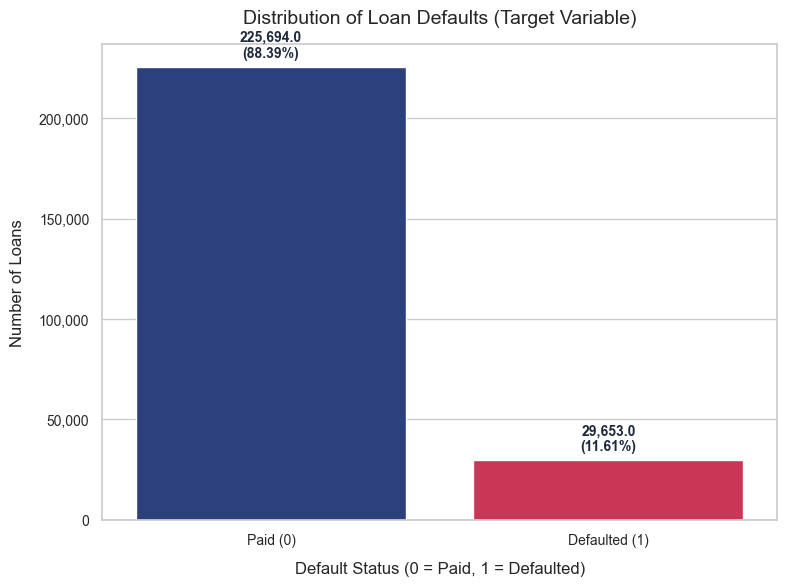

In [9]:
plt.figure(figsize=(8, 6))
colors = [PRIMARY_COLOR, ALERT_COLOR]

ax = sns.countplot(x='Default', data=df, palette=colors, hue='Default', legend=False)
plt.title('Distribution of Loan Defaults (Target Variable)', pad=15)
plt.xlabel('Default Status (0 = Paid, 1 = Defaulted)', labelpad=10)
plt.ylabel('Number of Loans', labelpad=10)
plt.xticks([0, 1], ['Paid (0)', 'Defaulted (1)'])

# Format y-axis values with commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add value and percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.2f}%'
    ax.annotate(f'{height:,}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold', color=NEUTRAL_DARK)

plt.tight_layout()
plt.show()

#### 9.2 Employment Type Distribution
We visualize the distribution of borrower employment categories. This helps identify the main occupational classes represented in the loan applicant pool.

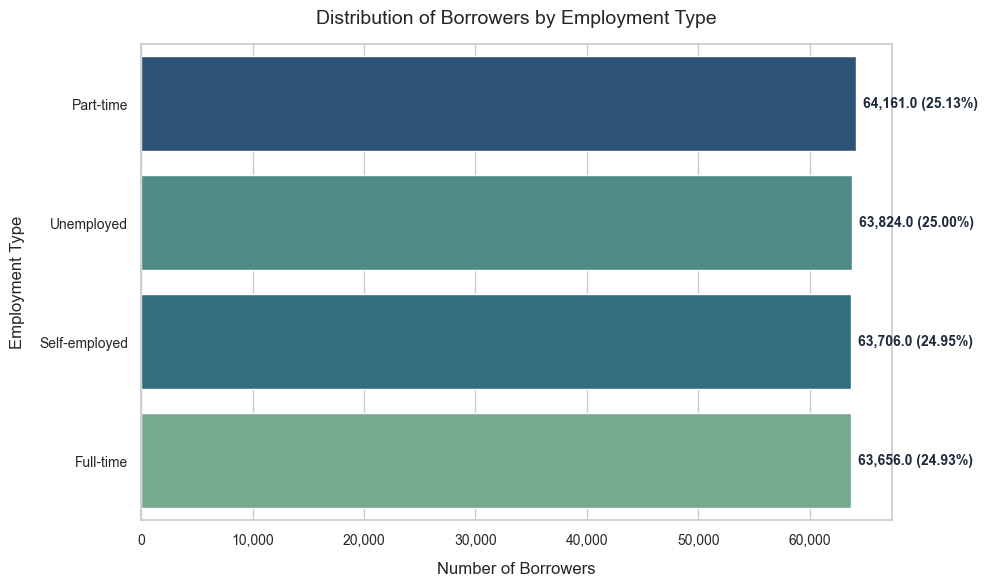

In [10]:
plt.figure(figsize=(10, 6))

emp_counts = df['EmploymentType'].value_counts()
emp_order = emp_counts.index

# Create horizontal bar plot with Teal-based gradient
ax = sns.countplot(y='EmploymentType', data=df, order=emp_order, palette='crest', hue='EmploymentType', legend=False)
plt.title('Distribution of Borrowers by Employment Type', pad=15)
plt.xlabel('Number of Borrowers', labelpad=10)
plt.ylabel('Employment Type', labelpad=10)

# Format x-axis values with commas
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add percentages and counts next to the bars
total = len(df)
for p in ax.patches:
    width = p.get_width()
    percentage = f'{100 * width / total:.2f}%'
    ax.annotate(f'{width:,} ({percentage})',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=NEUTRAL_DARK)

plt.tight_layout()
plt.show()

#### 9.3 Credit Score Distribution
This histogram visualizes the distribution of borrower credit scores. We add lines indicating the mean and median credit score, as well as thresholds for typical credit scoring tiers:
- **Poor**: $< 580$
- **Fair**: $580$ to $669$
- **Good**: $670$ to $799$
- **Excellent**: $\ge 800$

This helps us understand the credit profile of the borrowers.

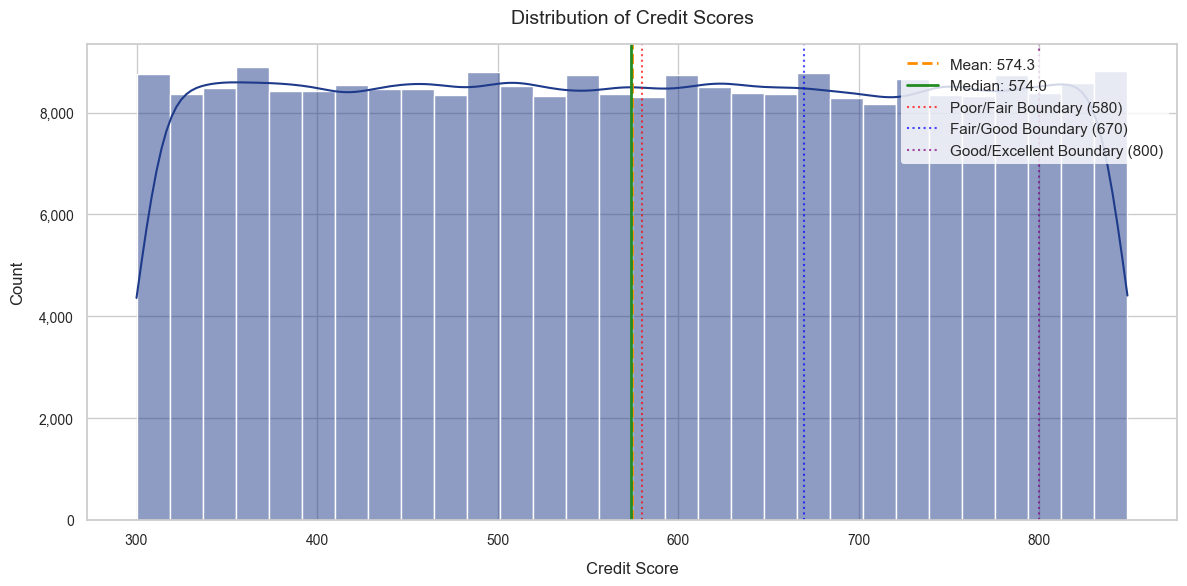

In [11]:
plt.figure(figsize=(12, 6))

# Plot histogram with KDE line
ax = sns.histplot(df['CreditScore'], bins=30, kde=True, color=PRIMARY_COLOR, edgecolor='w')
plt.title('Distribution of Credit Scores', pad=15)
plt.xlabel('Credit Score', labelpad=10)
plt.ylabel('Count', labelpad=10)

# Format y-axis values with commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Draw vertical lines for credit statistics and boundaries
mean_cs = df['CreditScore'].mean()
median_cs = df['CreditScore'].median()

plt.axvline(mean_cs, color='darkorange', linestyle='--', linewidth=2, label=f'Mean: {mean_cs:.1f}')
plt.axvline(median_cs, color='forestgreen', linestyle='-', linewidth=2, label=f'Median: {median_cs:.1f}')

# Reference lines for credit categories
plt.axvline(580, color='red', linestyle=':', alpha=0.7, label='Poor/Fair Boundary (580)')
plt.axvline(670, color='blue', linestyle=':', alpha=0.7, label='Fair/Good Boundary (670)')
plt.axvline(800, color='purple', linestyle=':', alpha=0.7, label='Good/Excellent Boundary (800)')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

#### 9.4 Age Distribution
We visualize the distribution of borrower age. This demographic profile provides insight into the age groups that apply for loans and default risks associated with age.

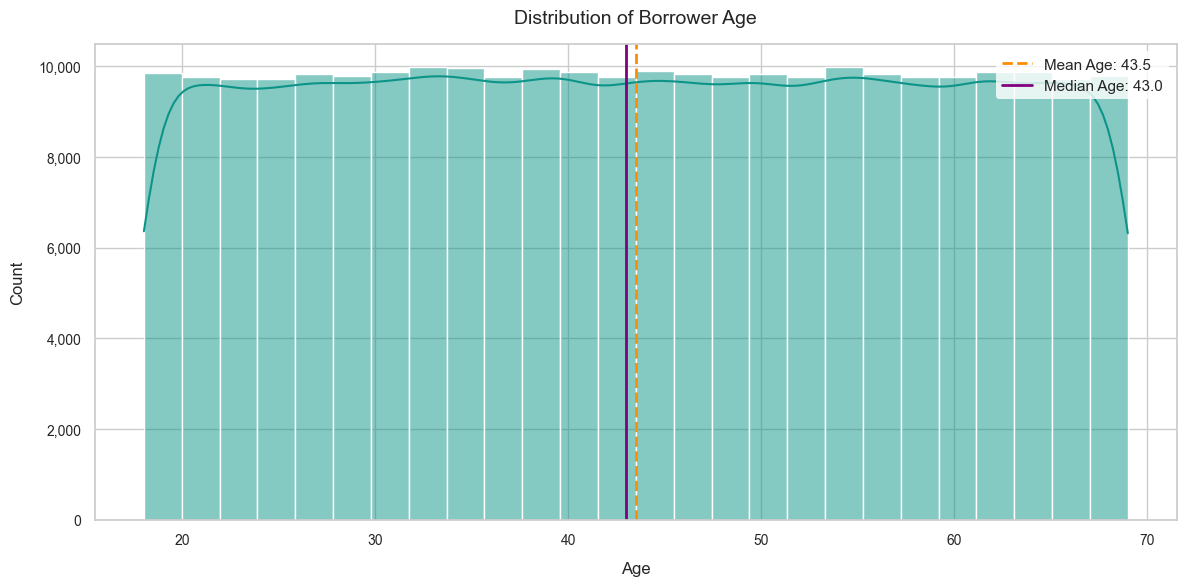

In [12]:
plt.figure(figsize=(12, 6))

# Plot histogram with KDE line
ax = sns.histplot(df['Age'], bins=26, kde=True, color=SECONDARY_COLOR, edgecolor='w')
plt.title('Distribution of Borrower Age', pad=15)
plt.xlabel('Age', labelpad=10)
plt.ylabel('Count', labelpad=10)

# Format y-axis values with commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Draw vertical lines for mean and median age
mean_age = df['Age'].mean()
median_age = df['Age'].median()

plt.axvline(mean_age, color='darkorange', linestyle='--', linewidth=2, label=f'Mean Age: {mean_age:.1f}')
plt.axvline(median_age, color='purple', linestyle='-', linewidth=2, label=f'Median Age: {median_age:.1f}')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

### 10. Key Observations & Modeling Implications

Based on our exploratory data analysis, we have uncovered several key insights about the dataset that will inform our data preprocessing, feature engineering, and model training strategies:

#### 1. Data Quality and Schema Integrity
* **No Missing Data**: The dataset contains zero missing values across all 255,347 records. This simplifies our processing pipeline because we do not need to perform imputation or drop missing values.
* **No Duplicate Records**: There are no duplicate rows, indicating data integrity.
* **Schema Layout**: There are 6 independent features (`Age`, `Income`, `LoanAmount`, `CreditScore`, `LoanTerm`, `EmploymentType`) and 1 target column (`Default`).
* **Categorical Variables**: `EmploymentType` is the only categorical text feature. It will require encoding (e.g., one-hot encoding or ordinal encoding) before feeding into Scikit-Learn models.

#### 2. Target Class Imbalance
* The target variable `Default` is significantly imbalanced, with a **11.61% default rate** (29,653 defaults) vs. an **88.39% non-default rate** (225,694 non-defaults).
* **Modeling Implication**: Using simple accuracy to evaluate our model will be misleading (a naive classifier predicting '0' for all cases would achieve 88.39% accuracy). We must focus on metrics like **F1-Score**, **Precision-Recall AUC (PR-AUC)**, and **ROC-AUC**. During model training, we should consider techniques like SMOTE (oversampling), downsampling, or setting class weights (e.g., `class_weight='balanced'` in Random Forest/Logistic Regression or using scale_pos_weight in XGBoost).

#### 3. Borrower Demographics & Distribution Profile
* **Employment Type**: The employment status is almost perfectly balanced across four groups: Part-time (25.13%), Unemployed (25.00%), Self-employed (24.95%), and Full-time (24.93%). This uniform distribution suggests there is no bias toward any particular employment group in the data collection process.
* **Credit Score Profile**: Credit scores are uniformly distributed between 300 and 849, with a mean score of 574.3. This represents a wide range of credit profiles, from subprime (poor credit) to super-prime (excellent credit). The uniform shape is unusual for real-world credit databases (which are typically skewed or bell-shaped), suggesting a synthetic or heavily normalized dataset.
* **Age Profile**: The age distribution is also highly uniform between 18 and 69 years, with an average age of 43.5. This uniform distribution ensures we have ample representation across young adults, middle-aged individuals, and older working populations.

#### Next Steps:
1. **Preprocessing & Feature Engineering**: 
   - Encode the `EmploymentType` column using One-Hot Encoding.
   - Scale numerical features (especially `Income`, `LoanAmount`, and `CreditScore`) for distance-based models (e.g., Logistic Regression, KNN, SVM) and neural networks.
   - Build a robust preprocessing pipeline using Scikit-Learn `ColumnTransformer`.
2. **Model Training & Evaluation**:
   - Establish a baseline model (e.g., Logistic Regression).
   - Train ensemble models (e.g., Random Forest, Gradient Boosting, XGBoost).
   - Optimize hyperparameters using grid/random search, focusing on ROC-AUC and F1-Score.